In [42]:
import sys
import os

project_root = os.path.abspath("..")
sys.path.append(project_root)

In [43]:
from typing_extensions import Literal

from langchain_core.messages import HumanMessage, AIMessage, get_buffer_string
from langgraph.graph import StateGraph, START, END
from langgraph.types import Command

In [44]:
from deep_research.utils import get_today_str
from deep_research.state import AgentState, ClarifyWithUser, ResearchQuestion, AgentInputState
from deep_research.prompt import transform_messages_into_research_topic_prompt, clarify_with_user_instructions

In [86]:
import getpass
import os

if "GOOGLE_API_KEY" not in os.environ:
    os.environ["GOOGLE_API_KEY"] = getpass.getpass("Enter your Google AI API key: ")

In [88]:
from langchain_google_genai import ChatGoogleGenerativeAI

In [96]:
model = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=1.0,    
    max_tokens=None,
    timeout=None
)

In [101]:
def clarify_with_user(state: AgentState) -> Command[Literal["write_research_brief", "__end__"]]:
    """
    Determine if the user's request contains sufficient information to proceed with research.
    
    Uses structured output to make deterministic decisions and avoid hallucination.
    Routes to either research brief generation or ends with a clarification question.
    """
    # Set up structured output model
    structured_output_model = model.with_structured_output(ClarifyWithUser)

    # Invoke the model with clarification instructions
    response = structured_output_model.invoke([
        HumanMessage(content=clarify_with_user_instructions.format(
            messages=get_buffer_string(messages=state["messages"]), 
            date=get_today_str()
        ))
    ])
    
    # Route based on clarification need
    if response.need_clarification:
        return Command(
            goto=END, 
            update={"messages": [AIMessage(content=response.question)]}
        )
    else:
        return Command(
            goto="write_research_brief", 
            update={"messages": [AIMessage(content=response.verification)]}
        )

In [102]:
def write_research_brief(state: AgentState):
    """
    Transform the conversation history into a comprehensive research brief.
    
    Uses structured output to ensure the brief follows the required format
    and contains all necessary details for effective research.
    """
    # Set up structured output model
    structured_output_model = model.with_structured_output(ResearchQuestion)
    
    # Generate research brief from conversation history
    response = structured_output_model.invoke([
        HumanMessage(content=transform_messages_into_research_topic_prompt.format(
            messages=get_buffer_string(state.get("messages", [])),
            date=get_today_str()
        ))
    ])
    
    # Update state with generated research brief and pass it to the supervisor
    return {
        "research_brief": response.research_brief,
        "supervisor_messages": [HumanMessage(content=f"{response.research_brief}.")]
    }

In [103]:
# ===== GRAPH CONSTRUCTION =====

# Build the scoping workflow
deep_researcher_builder = StateGraph(AgentState, input_schema=AgentInputState)

# Add workflow nodes
deep_researcher_builder.add_node("clarify_with_user", clarify_with_user)
deep_researcher_builder.add_node("write_research_brief", write_research_brief)

# Add workflow edges
deep_researcher_builder.add_edge(START, "clarify_with_user")
deep_researcher_builder.add_edge("write_research_brief", END)

# Compile the workflow
scope_research = deep_researcher_builder.compile()

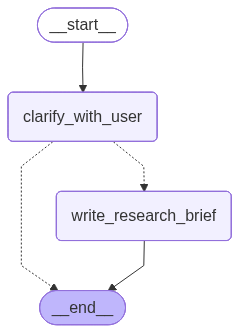

In [104]:
from IPython.display import Image, display
from langgraph.checkpoint.memory import InMemorySaver

checkpointer = InMemorySaver()
scope = deep_researcher_builder.compile(checkpointer=checkpointer)
display(Image(scope.get_graph(xray=True).draw_mermaid_png()))

In [105]:
from langchain_core.messages import HumanMessage
thread = {"configurable": {"thread_id": "1"}}
result = scope.invoke({"messages": [HumanMessage(content="I want to research the best IPL Team")]}, config=thread)
print(result['messages'])

[HumanMessage(content='I want to research the best IPL Team', additional_kwargs={}, response_metadata={}, id='de5a2944-69fe-4152-8601-daae1c680b5e'), AIMessage(content='To provide you with the most relevant research, could you please clarify what "IPL" stands for and what criteria you would like to use to determine the "best" team (e.g., most championships, highest win percentage, overall performance over a specific period)?', additional_kwargs={}, response_metadata={}, id='ee999af8-5fb6-4b13-b74e-cb24fd47481d', tool_calls=[], invalid_tool_calls=[])]


In [106]:
result = scope.invoke({"messages": [HumanMessage(content="More tropies with overall win percentage")]}, config=thread)
print(result['messages'])

[HumanMessage(content='I want to research the best IPL Team', additional_kwargs={}, response_metadata={}, id='de5a2944-69fe-4152-8601-daae1c680b5e'), AIMessage(content='To provide you with the most relevant research, could you please clarify what "IPL" stands for and what criteria you would like to use to determine the "best" team (e.g., most championships, highest win percentage, overall performance over a specific period)?', additional_kwargs={}, response_metadata={}, id='ee999af8-5fb6-4b13-b74e-cb24fd47481d', tool_calls=[], invalid_tool_calls=[]), HumanMessage(content='More tropies with overall win percentage', additional_kwargs={}, response_metadata={}, id='f8449b7d-7064-4985-8f70-2716d58f068e'), AIMessage(content='Could you please clarify what "IPL" stands for?', additional_kwargs={}, response_metadata={}, id='60d335b5-abec-4cb7-beab-534939e09b22', tool_calls=[], invalid_tool_calls=[])]


In [107]:
result["research_brief"]

KeyError: 'research_brief'